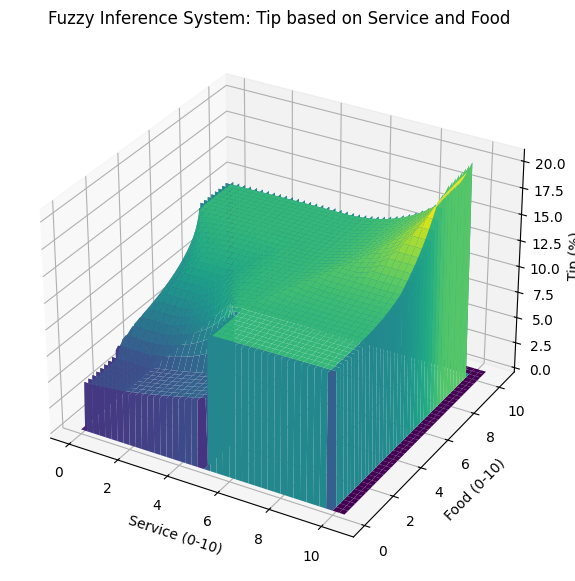

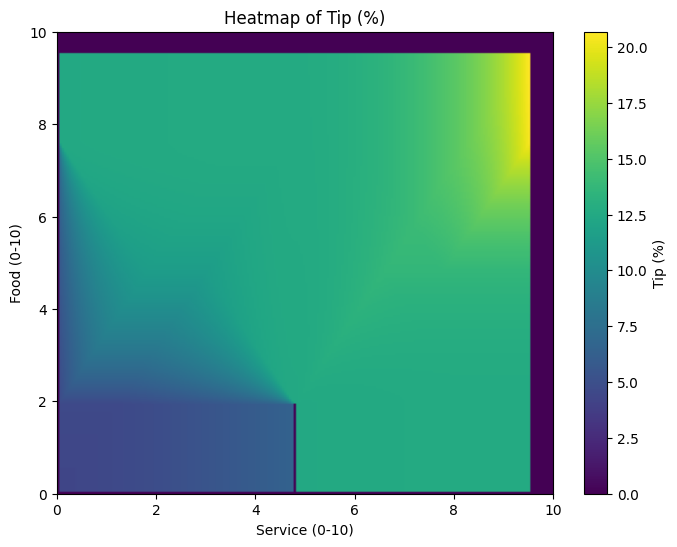

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Функция для треугольной функции принадлежности
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a)
    else:
        return (c - x) / (c - b)

# Определение нечетких множеств
# Service: poor (0,0,5), average (0,5,10), good (5,10,10)
def service_poor(x):
    return triangular_mf(x, 0, 0, 5)

def service_average(x):
    return triangular_mf(x, 0, 5, 10)

def service_good(x):
    return triangular_mf(x, 5, 10, 10)

# Food: rancid (0,0,5), delicious (5,10,10)
def food_rancid(x):
    return triangular_mf(x, 0, 0, 8)

def food_delicious(x):
    return triangular_mf(x, 2, 10, 10)

# Tip: low (0,0,13), medium (0,13,25), high (13,25,25)
def tip_low(y):
    return triangular_mf(y, 0, 0, 13)

def tip_medium(y):
    return triangular_mf(y, 0, 13, 25)

def tip_high(y):
    return triangular_mf(y, 13, 25, 25)

def calculate_tip(service: float, food: float, verbose: bool = False) -> float:
    # Шаг 2: Фаззификация
    mu_service_poor = service_poor(service)
    mu_service_average = service_average(service)
    mu_service_good = service_good(service)

    mu_food_rancid = food_rancid(food)
    mu_food_delicious = food_delicious(food)

    if verbose:
        print(f"Service: poor={mu_service_poor:.2f}, average={mu_service_average:.2f}, good={mu_service_good:.2f}")
        print(f"Food: rancid={mu_food_rancid:.2f}, delicious={mu_food_delicious:.2f}")

    # Шаг 3: Правила (используем min для AND)
    # Rule 1: IF service poor AND food rancid THEN tip low
    alpha1 = min(mu_service_poor, mu_food_rancid)

    # Rule 2: IF service average AND food delicious THEN tip medium
    alpha2 = min(mu_service_average, mu_food_delicious)

    # Rule 3: IF service good AND food delicious THEN tip high
    alpha3 = min(mu_service_good, mu_food_delicious)

    # Rule 4: IF service good AND food rancid THEN tip medium
    alpha4 = min(mu_service_good, mu_food_rancid)

    # Шаг 4: Агрегация - дискретизируем выход от 0 до 25
    y = np.linspace(0, 25, 1000)  # Для точности
    mu_tip = np.zeros_like(y)

    # Усечение и max для агрегации
    for i, val in enumerate(y):
        mu_low_clipped = min(tip_low(val), alpha1)
        mu_medium_clipped1 = min(tip_medium(val), alpha2)
        mu_medium_clipped2 = min(tip_medium(val), alpha4)
        mu_high_clipped = min(tip_high(val), alpha3)

        # Агрегация: max из всех clipped
        mu_tip[i] = max(mu_low_clipped, mu_medium_clipped1, mu_medium_clipped2, mu_high_clipped)

    # Шаг 5: Дефаззификация - центр тяжести
    if np.sum(mu_tip) > 0:
        tip_crisp = np.sum(y * mu_tip) / np.sum(mu_tip)
        if verbose:
            print(f"Calculated tip: {tip_crisp:.2f}%")
        return tip_crisp
    else:
        if verbose:
            print("No rules fired, tip: 0%")
        return 0.0

# Демонстрация на разных данных: сетка значений service и food с шагом 0.5
services = np.arange(0, 10.5, 0.05)
foods = np.arange(0, 10.5, 0.05)
S, F = np.meshgrid(services, foods)
tips = np.zeros_like(S)

for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        tips[i, j] = calculate_tip(S[i, j], F[i, j])

# Визуализация: 3D поверхность
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S, F, tips, cmap='viridis')

ax.set_xlabel('Service (0-10)')
ax.set_ylabel('Food (0-10)')
ax.set_zlabel('Tip (%)')
ax.set_title('Fuzzy Inference System: Tip based on Service and Food')

plt.show()

# Альтернативная визуализация: heatmap (2D)
fig2, ax2 = plt.subplots(figsize=(8, 6))
im = ax2.imshow(tips, cmap='viridis', extent=[0, 10, 0, 10], origin='lower', aspect='auto')
ax2.set_xlabel('Service (0-10)')
ax2.set_ylabel('Food (0-10)')
ax2.set_title('Heatmap of Tip (%)')
fig2.colorbar(im, ax=ax2, label='Tip (%)')

plt.show()

# # Пример для конкретных значений (как в исходном)
# print("\nExample for service=9.8, food=6.5:")
# calculate_tip(9.8, 6.5, verbose=True)